In [1]:
import numpy as np
import tensorflow as tf

%matplotlib inline
import matplotlib.pyplot as plt
# Import or install Sionna
from sionna.rt import load_scene, Transmitter, Receiver, PlanarArray, Camera, PathSolver, RadioMapSolver, subcarrier_frequencies
import mitsuba as mi
import json
import os
from pathlib import Path


jitc_llvm_init(): LLVM API initialization failed ..


In [2]:
PROJECT_DIR = Path.cwd().parent
SCENE_DIR = PROJECT_DIR / "scene"
OUTPUT_DIR = PROJECT_DIR / "output"

In [4]:
RUNTIME_CONF = PROJECT_DIR / "runtime_config.json"

with open(RUNTIME_CONF, "r") as f:
    runtime_config = json.load(f)

In [5]:
scene_path = SCENE_DIR / "m_palace" / "m_palace.xml"
scene = load_scene(scene_path)
print(scene)
print("Objects:", len(scene.objects))
print(scene.objects.keys())

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\ludav\\workshop\\CNR\\RFSim\\scene\\m_palace\\m_palace.xml'

In [16]:
# Create new camera with different configuration
my_cam = Camera(position=[0,400,-400], look_at=[0,0,0])

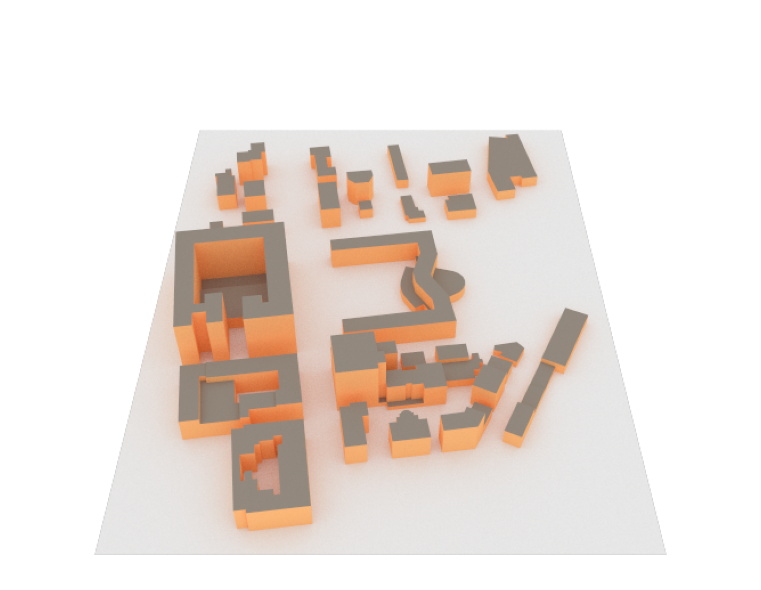

In [17]:
# Render scene with new camera
scene.render(camera=my_cam, resolution=[650, 500], num_samples=512); # Increase num_samples to increase image quality

In [22]:
# Configure antenna array for all transmitters
scene.tx_array = PlanarArray(num_rows=6,
                             num_cols=6,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="V")

# Configure antenna array for all transmitters
scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="dipole",
                             polarization="cross")


In [42]:
# Create transmitter
tx = Transmitter(name="tx",
                 position=[-30,30,0],
                 display_radius=2)

# Add transmitter instance to scene
scene.add(tx)

In [43]:
# Create receiver
rx = Receiver(name="rx",
                 position=[40,1,20],
                 display_radius=2)

# Add receiver instance to scene
scene.add(rx)

In [41]:
if tx:
    scene.remove("tx")

if rx:
    scene.remove("rx")

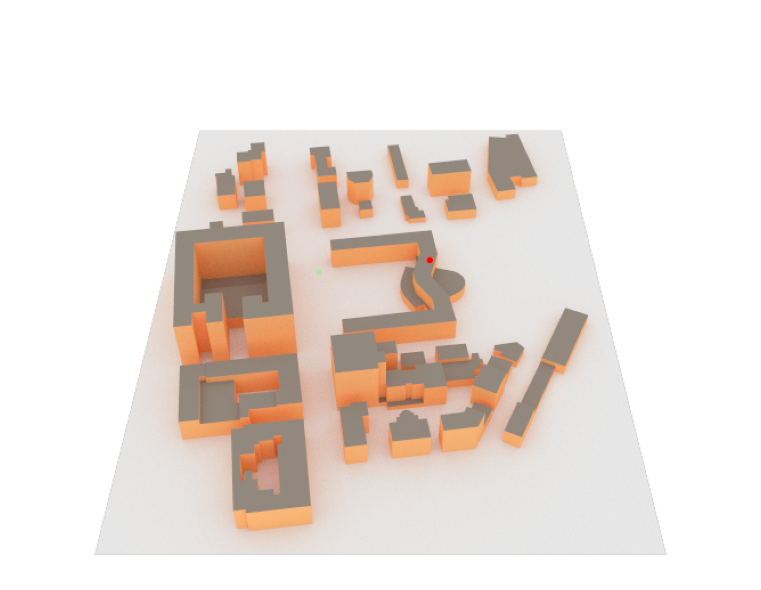

: 

In [ ]:
# Render scene with new camera
scene.render(camera=my_cam, resolution=[650, 500], num_samples=512); # Increase num_samples to increase image quality

In [ ]:
# posizionare n tx
# posizionare m rx (o spostarne/crearne 1 ad ogni step)
# per ogni rx, per ogni tx salvare metriche di rx e link rx-tx

# ToDo
1.   Check the coordinate system difference between Blender and Sionna by placing fixed tx (and eventually check of to syncronize the system)
**Sionna coordinates x,y,z -> -x,z,y**
2.   Check how to place variable rx outside of building boxes **To do it, we need to get the building footprints from the .ply files and save them in the scene .json, then from these footprints we can precompute rx and tx valid positioons**
3. Check which metrics and how to save them

# Sionna Test

In [ ]:
scene = load_scene("/content/drive/MyDrive/Sionna/map/m_palace/m_palace.xml", merge_shapes=False)
scene.objects

{'elm__2': <sionna.rt.scene_object.SceneObject at 0x7b8b92968500>,
 'elm__5': <sionna.rt.scene_object.SceneObject at 0x7b8ad456c920>,
 'elm__6': <sionna.rt.scene_object.SceneObject at 0x7b8b92cfde80>,
 'elm__7': <sionna.rt.scene_object.SceneObject at 0x7b8ad456e6c0>,
 'elm__8': <sionna.rt.scene_object.SceneObject at 0x7b8ad456c260>,
 'elm__9': <sionna.rt.scene_object.SceneObject at 0x7b8ad450cc80>,
 'elm__10': <sionna.rt.scene_object.SceneObject at 0x7b8ad450ff20>,
 'elm__11': <sionna.rt.scene_object.SceneObject at 0x7b8ad450e9c0>,
 'elm__12': <sionna.rt.scene_object.SceneObject at 0x7b8ad450fa70>,
 'elm__13': <sionna.rt.scene_object.SceneObject at 0x7b8ad450f320>,
 'elm__14': <sionna.rt.scene_object.SceneObject at 0x7b8ad450dcd0>,
 'elm__15': <sionna.rt.scene_object.SceneObject at 0x7b8ae0175a90>,
 'elm__16': <sionna.rt.scene_object.SceneObject at 0x7b8ad4561220>,
 'elm__17': <sionna.rt.scene_object.SceneObject at 0x7b8ad45613d0>,
 'elm__18': <sionna.rt.scene_object.SceneObject at 0x7

In [ ]:
scene = load_scene(sionna.rt.scene.munich, merge_shapes=True) # Merge shapes to speed-up computations

# Configure antenna array for all transmitters
scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="V")

# Configure antenna array for all receivers
scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="dipole",
                             polarization="cross")

# Create transmitter
tx = Transmitter(name="tx",
                 position=[8.5,21,27],
                 display_radius=2)

# Add transmitter instance to scene
scene.add(tx)

# Create a receiver
rx = Receiver(name="rx",
              position=[45,90,1.5],
              display_radius=2)

# Add receiver instance to scene
scene.add(rx)

tx.look_at(rx) # Transmitter points towards receiver

In [ ]:
# Instantiate a path solver
# The same path solver can be used with multiple scenes
p_solver  = PathSolver()

# Compute propagation paths
paths = p_solver(scene=scene,
                 max_depth=5)

In [ ]:
# Create new camera with different configuration
top_cam = Camera(position=[0,750,-250], look_at=[0,0,0])

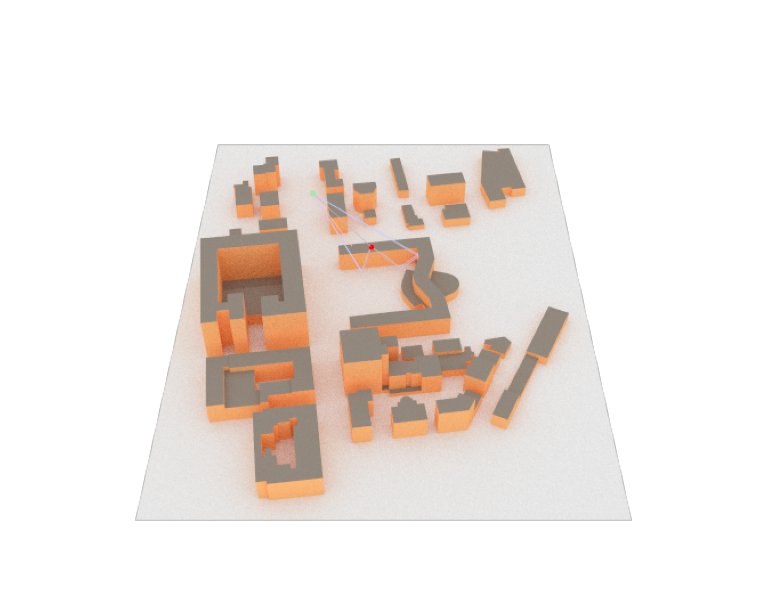

In [ ]:
scene.render(camera=my_cam, paths=paths);

In [ ]:
a, tau = paths.cir(normalize_delays=True, out_type="numpy")

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
print("Shape of a: ", a.shape)

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
print("Shape of tau: ", tau.shape)

Shape of a:  (1, 2, 1, 1, 6, 1)
Shape of tau:  (1, 1, 6)


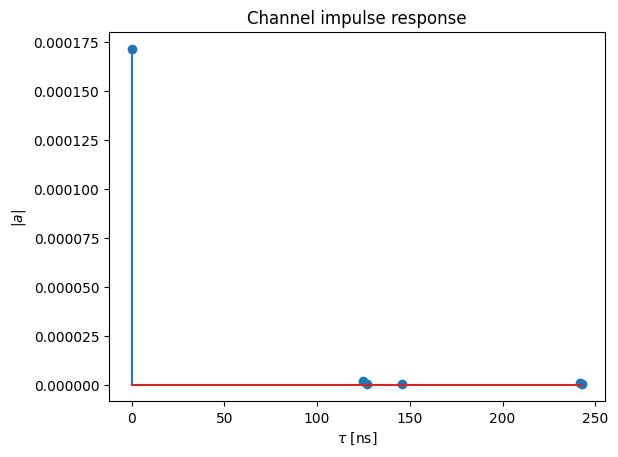

In [ ]:
t = tau[0,0,:]/1e-9 # Scale to ns
a_abs = np.abs(a)[0,0,0,0,:,0]
a_max = np.max(a_abs)

# And plot the CIR
plt.figure()
plt.title("Channel impulse response")
plt.stem(t, a_abs)
plt.xlabel(r"$\tau$ [ns]")
plt.ylabel(r"$|a|$ ");

Shape of h_freq:  (1, 2, 1, 1, 1, 1024)


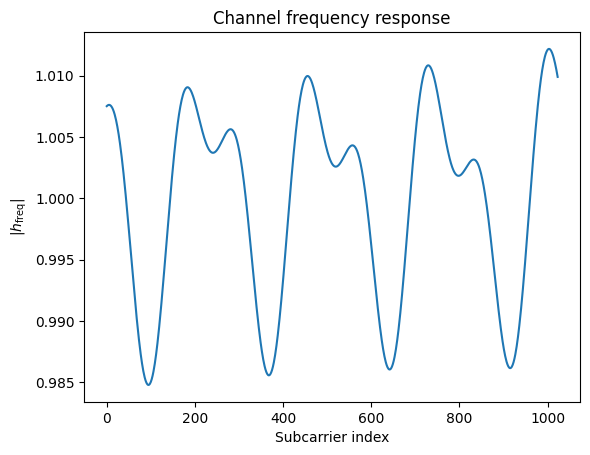

In [ ]:
# OFDM system parameters
num_subcarriers = 1024
subcarrier_spacing=30e3

# Compute frequencies of subcarriers relative to the carrier frequency
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)

# Compute channel frequency response
h_freq = paths.cfr(frequencies=frequencies,
                   normalize=True, # Normalize energy
                   normalize_delays=True,
                   out_type="numpy")

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_time_steps, num_subcarriers]
print("Shape of h_freq: ", h_freq.shape)

# Plot absolute value
plt.figure()
plt.plot(np.abs(h_freq)[0,0,0,0,0,:]);
plt.xlabel("Subcarrier index");
plt.ylabel(r"|$h_\text{freq}$|");
plt.title("Channel frequency response");

Shape of taps:  (1, 2, 1, 1, 1, 107)


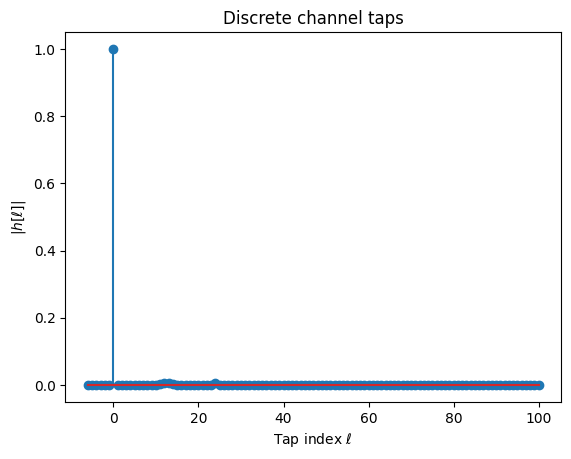

In [ ]:
taps = paths.taps(bandwidth=100e6, # Bandwidth to which the channel is low-pass filtered
                  l_min=-6,        # Smallest time lag
                  l_max=100,       # Largest time lag
                  sampling_frequency=None, # Sampling at Nyquist rate, i.e., 1/bandwidth
                  normalize=True,  # Normalize energy
                  normalize_delays=True,
                  out_type="numpy")
print("Shape of taps: ", taps.shape)

plt.figure()
plt.stem(np.arange(-6, 101), np.abs(taps)[0,0,0,0,0]);
plt.xlabel(r"Tap index $\ell$");
plt.ylabel(r"|$h[\ell]|$");
plt.title("Discrete channel taps");

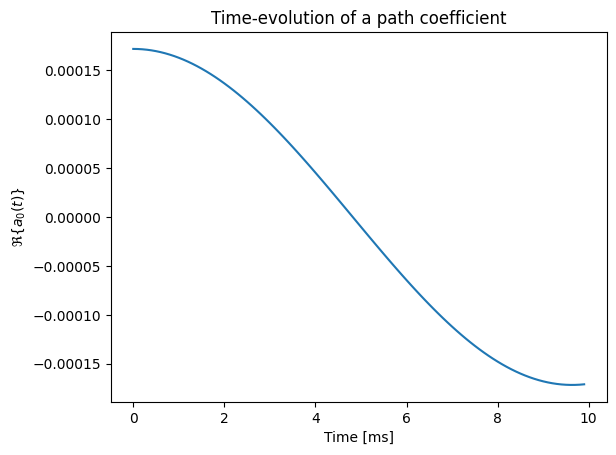

In [ ]:
scene.get("tx").velocity = [10, 0, 0]

# Recompute propagation paths
paths_mob = p_solver(scene=scene,
                     max_depth=5,
                     los=True,
                     specular_reflection=True,
                     diffuse_reflection=False,
                     refraction=True,
                     synthetic_array=True,
                     seed=41)

# Compute CIR with time-evolution
num_time_steps=100
sampling_frequency = 1e4
a_mob, _ = paths_mob.cir(sampling_frequency=sampling_frequency,
                         num_time_steps=num_time_steps,
                         out_type="numpy")

# Inspect time-evolution of a single path coefficient
plt.figure()
plt.plot(np.arange(num_time_steps)/sampling_frequency*1000,
         a_mob[0,0,0,0,0].real);
plt.xlabel("Time [ms]");
plt.ylabel(r"$\Re\{a_0(t) \}$");
plt.title("Time-evolution of a path coefficient");

In [ ]:
import numpy as np

bbox = scene.mi_scene.bbox()

bbox_min = np.array(bbox.min)
bbox_max = np.array(bbox.max)

x_min, y_min, z_min = bbox_min
x_max, y_max, z_max = bbox_max

x_size = x_max - x_min
z_size = z_max - z_min

print("x_size:", x_size)
print("z_size", z_size)

x_size: 280.0
z_size 360.0


In [ ]:
rm_solver = RadioMapSolver()

rm = rm_solver(scene=scene,
               max_depth=5,
               cell_size=[3, 3],
               center=[0, 1.5, 0],
               size=[int(x_size), int(z_size)],
               orientation=[0, 0, np.pi/2],
               samples_per_tx=10**7) # rotate XY plane into XZ plane)

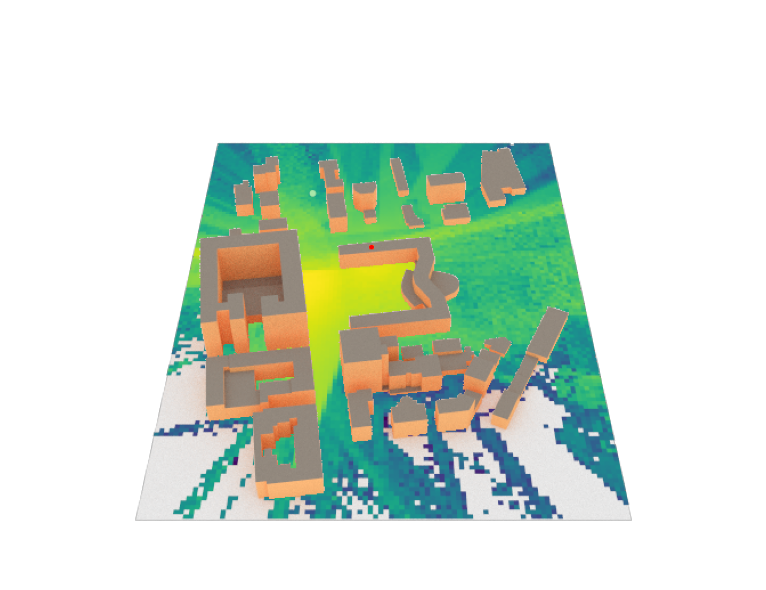

In [ ]:
scene.render(camera=my_cam, radio_map=rm);